# Library

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import numpy as np

from sklearn.feature_selection import RFE as rfe, SequentialFeatureSelector as sfs, chi2, SelectKBest as skb

from sklearn.model_selection import train_test_split as tts
from sklearn.preprocessing import OneHotEncoder as ohe, StandardScaler as ss, MinMaxScaler as mms
from sklearn.compose import ColumnTransformer as ct
from sklearn.linear_model import LinearRegression as lr_, LogisticRegression as lr
from sklearn.metrics import accuracy_score as AS, classification_report as cr
from sklearn.ensemble import RandomForestClassifier as rfr
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as lda

from sklearn.decomposition import PCA as pca, KernelPCA as kpca


# Data

In [2]:
# Load Dataset
data = pd.read_csv(r"E:\DATA FOR TEST\Tele Customer churn\WA_Fn-UseC_-Telco-Customer-Churn _1.csv")
df = data.copy()
print(data.InternetService.head(10))

0            DSL
1            DSL
2            DSL
3            DSL
4    Fiber optic
5    Fiber optic
6    Fiber optic
7            DSL
8    Fiber optic
9            DSL
Name: InternetService, dtype: object


In [3]:
# EDA
df.drop(columns=['customerID'], inplace=True, axis = 1)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df['tenure'] = df['tenure'].fillna(df['tenure'].mean())
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])
df.dropna(how='any', inplace=True)

In [4]:
# Split Data in X and Y Variable
x = df.iloc[:, :-1]
y = df.iloc[:, -1].map({'Yes': 1, 'No': 0})

In [5]:
# Split Data in Training and Testing
x_train, x_test, y_train, y_test = tts(x, y, test_size=0.2, stratify=y, random_state = 42)


In [6]:
# Feature Encoding
cat_col = x_train.select_dtypes(include=['category', 'object']).columns

encoder = ct(transformers = [(
    'encoder', ohe(handle_unknown='ignore', drop='first'), cat_col
)],
             remainder='passthrough'
            )

x_train = encoder.fit_transform(x_train)
x_test = encoder.transform(x_test)
cat_col

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [7]:
# Feture Scaling
scaler = ss()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# RFS Model

In [8]:
# Build Base Model 
lr_model = lr(random_state = 42, max_iter =100)
lr_model.fit(x_train, y_train)
y_pred_lr = lr_model.predict(x_test)

# Results
accuracy = AS(y_test, y_pred_lr)
print(accuracy*100)

79.27608232789211


In [9]:
# Regression Feature Element Model Initilization
rec_f_e = rfe(lr(random_state = 42, max_iter =100), n_features_to_select = 5)
rec_f_e.fit(x_train, y_train)

# Selected Features by RFC
feature_name = encoder.get_feature_names_out()
selected_features = feature_name[rec_f_e.support_]

y_pred_rfe = rec_f_e.predict(x_test)

# Results
accuracy = AS(y_test, y_pred_rfe)
print(accuracy*100)

77.35982966643009


In [10]:
# logestic Regression Model Initilization
log_reg = lr(random_state = 42, max_iter =100)

# Selected Features by RFC
feature_name = encoder.get_feature_names_out()
selected_features = feature_name[rec_f_e.support_]

# Select only Columns of RFC
x_train_sel = x_train[:, rec_f_e.support_]
x_test_sel = x_test[:, rec_f_e.support_]

log_reg.fit(x_train_sel, y_train)
y_pred_rfe = log_reg.predict(x_test_sel)

# Results
accuracy = AS(y_test, y_pred_rfe)
print(accuracy*100)

77.35982966643009


In [11]:
Accuracy_Score = []
for i in range(1, 31):
   # logestic Regression Model Initilization
    log_reg = lr(random_state = 42, max_iter =100)
    
    # Regression Feature Element Model Initilization
    rec_f_e = rfe(log_reg, n_features_to_select = i)
    rec_f_e.fit(x_train, y_train) 
    
    # Selected Features by RFC
    feature_name = encoder.get_feature_names_out()
    selected_features = feature_name[rec_f_e.support_]
    
    # Select only Columns of RFC
    x_train_sel = x_train[:, rec_f_e.support_]
    x_test_sel = x_test[:, rec_f_e.support_]

    # logestic Regression Model Initilization
    log_reg = lr(random_state = 42, max_iter =100)    
    log_reg.fit(x_train_sel, y_train)
    y_pred_rfe = log_reg.predict(x_test_sel)
    
    # Results
    accuracy = AS(y_test, y_pred_rfe)
    print(accuracy*100)
    Accuracy_Score.append(accuracy)

73.24343506032646
77.43080198722498
77.35982966643009
77.35982966643009
77.35982966643009
77.35982966643009
77.71469127040454
77.71469127040454
77.50177430801988
78.56635911994321
78.56635911994321
79.20511000709723
78.85024840312278
78.85024840312278
79.27608232789211
79.55997161107167
79.55997161107167
79.347054648687
79.347054648687
79.347054648687
79.347054648687
79.27608232789211
79.13413768630234
79.06316536550744
79.347054648687
79.347054648687
79.4180269694819
79.347054648687
79.27608232789211
79.27608232789211


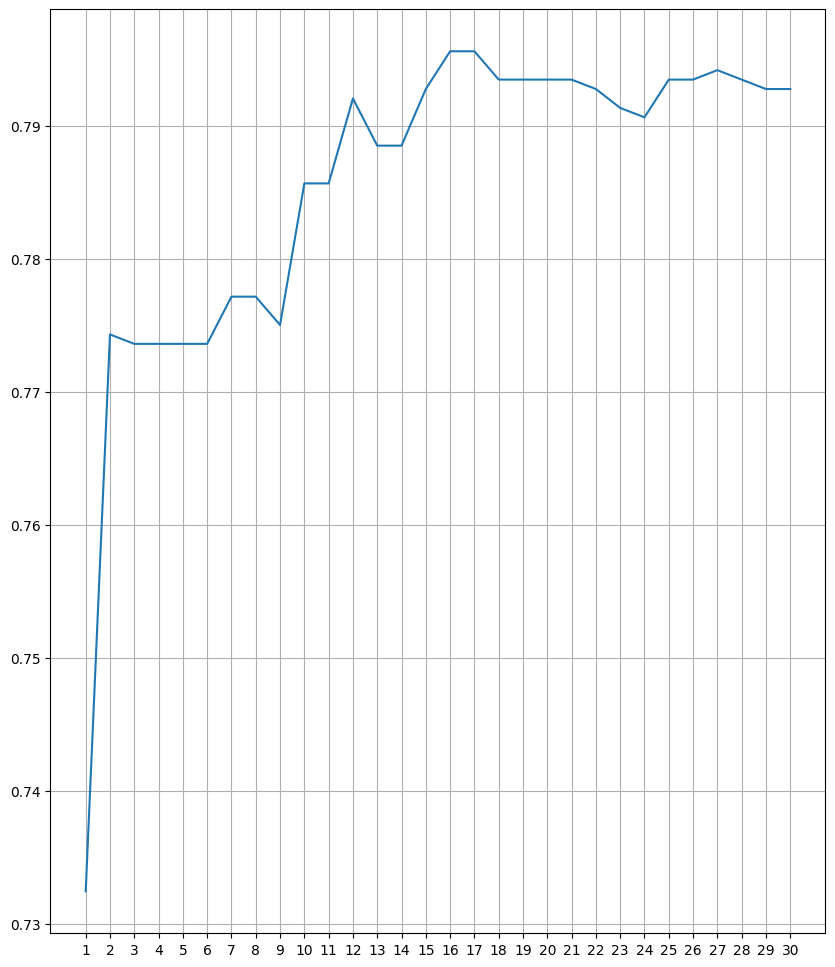

In [13]:
plt.figure(figsize=(10, 12))
plt.plot(range(1, 31), Accuracy_Score)
plt.grid()
plt.xticks(range(1, 31))
plt.show()

In [14]:
# logestic Regression Model Initilization
log_reg = lr(random_state = 42, max_iter =1000)

# Regression Feature Element Model Initilization
rec_f_e = rfe(log_reg, n_features_to_select = 2)
rec_f_e.fit(x_train, y_train)

# Selected Features by RFC
feature_name = encoder.get_feature_names_out()
selected_features = feature_name[rec_f_e.support_]

y_pred_rfe = rec_f_e.predict(x_test)

# Results
accuracy = AS(y_test, y_pred_rfe)
print(accuracy*100)

77.43080198722498


In [15]:
selected_features

array(['encoder__InternetService_Fiber optic', 'remainder__tenure'],
      dtype=object)

# SFS Model

In [16]:
# Build Base Model 
lr_model = lr(random_state = 42, max_iter =100)
lr_model.fit(x_train, y_train)
y_pred_lr = lr_model.predict(x_test)

# Results
accuracy = AS(y_test, y_pred_lr)
print(accuracy*100)

79.27608232789211


In [17]:
# Logistic Regression Model
log_reg = lr(random_state=42, max_iter=1000)

# Sequential Feature Selection
sfs_model = sfs(log_reg, n_features_to_select=5)
sfs_model.fit(x_train, y_train)

# Get feature names
feature_name = encoder.get_feature_names_out()
selected_features = feature_name[sfs_model.support_]

# Convert numpy arrays to DataFrame
x_train_sel = x_train[:, sfs_model.support_]
x_test_sel = x_test[:, sfs_model.support_]

# Train model on selected features
log_reg.fit(x_train_sel, y_train)

# Predict
y_pred_sfs = log_reg.predict(x_test_sel)

# Accuracy
accuracy = AS(y_test, y_pred_sfs)
print(accuracy * 100)


78.49538679914833


In [18]:
Accuracy_Score = []

n_features = x_train.shape[1]   # total features after encoding

for i in range(1, n_features):
   # logestic Regression Model Initilization
    log_reg = lr(random_state = 42, max_iter =100)
    
    # Regression Feature Element Model Initilization
    sfs_model = sfs(log_reg, n_features_to_select = i)
    sfs_model.fit(x_train, y_train)
    
    # Selected Features by SFS
    feature_name = encoder.get_feature_names_out()
    selected_features = feature_name[sfs_model.support_]
    
    # Select only Columns of SFS
    x_train_sel = x_train[:, sfs_model.support_]
    x_test_sel = x_test[:, sfs_model.support_]

    # logestic Regression Model Initilization
    log_reg = lr(random_state = 42, max_iter =100)    
    log_reg.fit(x_train_sel, y_train)
    y_pred_sfs = log_reg.predict(x_test_sel)
    
    # Results
    accuracy = AS(y_test, y_pred_sfs)
    print(accuracy*100)
    Accuracy_Score.append(accuracy)

73.45635202271114
73.45635202271114
74.37899219304471
77.85663591199432
78.49538679914833
78.63733144073811
78.99219304471256
79.20511000709723
79.20511000709723
79.4180269694819
79.55997161107167
79.4180269694819
79.20511000709723
79.13413768630234
79.13413768630234
79.20511000709723
79.55997161107167
79.4889992902768
79.4889992902768
79.06316536550744
79.77288857345636
79.77288857345636
79.77288857345636
79.77288857345636
79.77288857345636
79.77288857345636
79.77288857345636
79.77288857345636
79.55997161107167


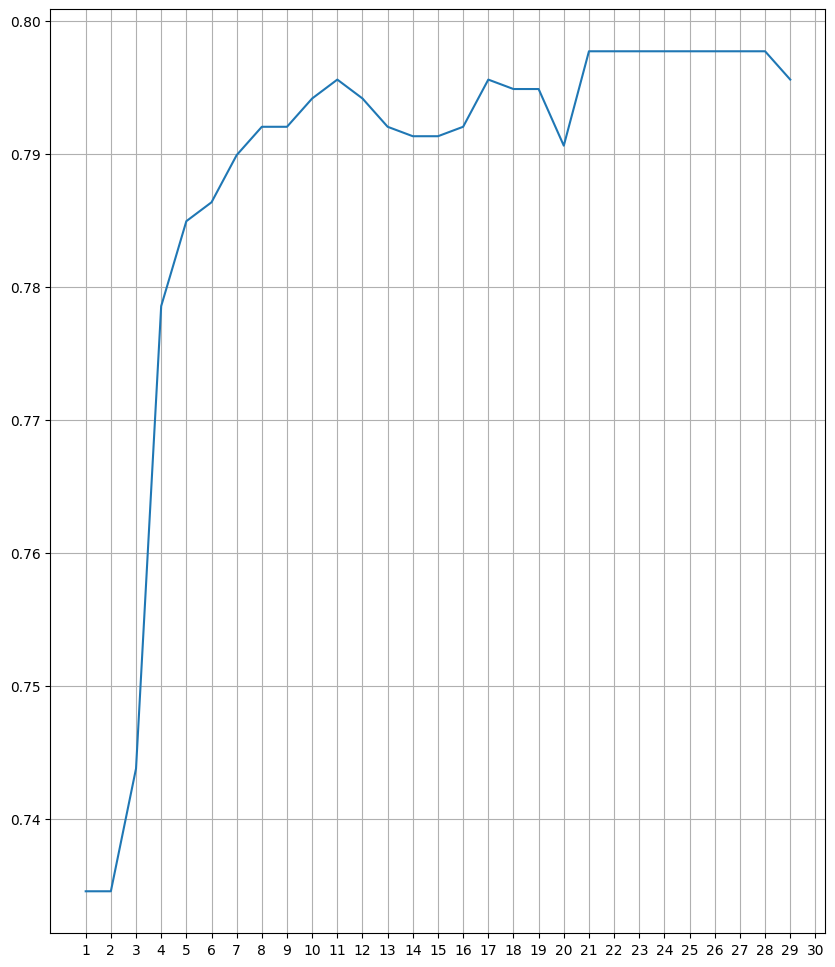

In [19]:
plt.figure(figsize=(10, 12))
plt.plot(range(1, n_features), Accuracy_Score)
plt.grid()
plt.xticks(range(1, 31))
plt.show()

In [20]:
selected_features

array(['encoder__gender_Male', 'encoder__Partner_Yes',
       'encoder__Dependents_Yes', 'encoder__PhoneService_Yes',
       'encoder__MultipleLines_No phone service',
       'encoder__MultipleLines_Yes',
       'encoder__InternetService_Fiber optic',
       'encoder__InternetService_No',
       'encoder__OnlineSecurity_No internet service',
       'encoder__OnlineSecurity_Yes',
       'encoder__OnlineBackup_No internet service',
       'encoder__OnlineBackup_Yes',
       'encoder__DeviceProtection_No internet service',
       'encoder__DeviceProtection_Yes',
       'encoder__TechSupport_No internet service',
       'encoder__TechSupport_Yes',
       'encoder__StreamingTV_No internet service',
       'encoder__StreamingTV_Yes',
       'encoder__StreamingMovies_No internet service',
       'encoder__StreamingMovies_Yes', 'encoder__Contract_One year',
       'encoder__PaperlessBilling_Yes',
       'encoder__PaymentMethod_Credit card (automatic)',
       'encoder__PaymentMethod_Electronic

# Chi Square Feature Selection

In [27]:
# Feature Encoding
x_train = pd.DataFrame(x_train)
x_test = pd.DataFrame(x_test)

cat_col = x_train.select_dtypes(include=['category', 'object']).columns

encoder = ct(transformers = [(
    'encoder', ohe(handle_unknown='ignore', drop='first'), cat_col
)],
             remainder='passthrough'
            )

x_train = encoder.fit_transform(x_train)
x_test = encoder.transform(x_test)


# Feature Scaling
scaler = mms()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [28]:
# apply chi2
chi2 = skb(chi2, k=5)
x_train_chi2 = chi2.fit_transform(x_train, y_train)
x_test_chi2 = chi2.transform(x_test)

In [33]:
# Build Model By Chi 2
model_chi2 = lr()
model_chi2.fit(x_train_chi2, y_train)

y_pred = model_chi2.predict(x_test_chi2)

accruracy = AS(y_test, y_pred)
accruracy

0.7501774308019872

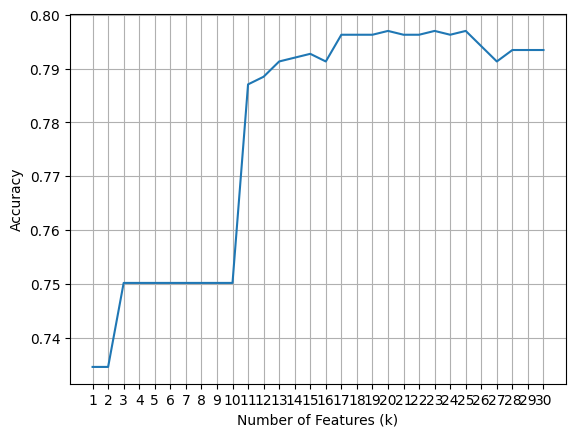

In [39]:
from sklearn.feature_selection import RFE as rfe, SequentialFeatureSelector as sfs, chi2, SelectKBest as skb


accuracy = []

for i in range(1, 31):
    
    # apply chi2 feature selection
    chi2_selector = skb(score_func=chi2, k=i)
    
    x_train_chi2 = chi2_selector.fit_transform(x_train, y_train)
    x_test_chi2 = chi2_selector.transform(x_test)
    
    # Build model
    model_chi2 = lr()
    model_chi2.fit(x_train_chi2, y_train)
    
    y_pred = model_chi2.predict(x_test_chi2)
    
    acc = AS(y_test, y_pred)
    accuracy.append(acc)

plt.plot(range(1, 31), accuracy)
plt.grid(True)
plt.xlabel("Number of Features (k)")
plt.ylabel("Accuracy")
plt.xticks(range(1, 31))
plt.show()


# PCA

In [11]:
# Feature Encoding
encoder = ohe(handle_unknown='ignore')
x_train_en = encoder.fit_transform(x_train)
x_test_en = encoder.transform(x_test)

# Feature Scaling
scaler = ss(with_mean=False)
x_train_sc = scaler.fit_transform(x_train_en)
x_treain_sc = scaler.transform(x_test_en)

# PCA Model
pca_model = pca(n_components=5)
x_train_pca = pca_model.fit_transform(x_train)
x_test_pca = pca_model.transform(x_test)

Explained_Variance = pca_model.explained_variance_ratio_
print(Explained_Variance)

[9.99860818e-01 1.19012956e-04 1.94760677e-05 1.22037384e-07
 6.52465997e-08]


In [14]:
# Build Base Model 
pca_lr_model = lr(random_state = 42, max_iter =1000)
pca_lr_model.fit(x_train_pca, y_train)
y_pred_lr = pca_lr_model.predict(x_test_pca)

# Results
accuracy = AS(y_test, y_pred_lr)
print(accuracy*100)

78.56635911994321


In [23]:
Accuracy = []
for i in range(1, 31):
    
    # PCA Model
    pca_model = pca(n_components=i)
    x_train_pca = pca_model.fit_transform(x_train)
    x_test_pca = pca_model.transform(x_test)

    # Build Base Model 
    pca_lr_model = lr(random_state = 42, max_iter =1000)
    pca_lr_model.fit(x_train_pca, y_train)
    y_pred_lr = pca_lr_model.predict(x_test_pca)
    
    # Results
    accuracy = AS(y_test, y_pred_lr)
    print(accuracy*100)
    Accuracy.append(accuracy)

73.45635202271114
77.64371894960965
77.43080198722498
77.2888573456352
78.56635911994321
79.27608232789211
79.347054648687
79.4180269694819
79.70191625266146
79.91483321504613
79.13413768630234
79.4180269694819
79.84386089425124
79.84386089425124
79.91483321504613
79.55997161107167
79.55997161107167
79.70191625266146
79.4180269694819
79.70191625266146


C:\Users\puruj\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


79.06316536550744


C:\Users\puruj\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


79.27608232789211


...

C:\Users\puruj\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


79.4889992902768


C:\Users\puruj\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


79.55997161107167
79.55997161107167


C:\Users\puruj\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# LDA

In [10]:
lda_model = lda()
x_train_lda = lda_model.fit_transform(x_train, y_train)
x_test_lda = lda_model.transform(x_test)

model_lda = lr()
model_lda.fit(x_train_lda, y_train)

y_pred_lda = model_lda.predict(x_test_lda)

# Result
accuracy = AS(y_test, y_pred_lda)
accuracy

0.7920511000709723

# KPCA (Kernal Principal Component Analysis)
For Non Linear Data

In [17]:
# Feature Encoding
encoder = ohe(handle_unknown='ignore')
x_train_en = encoder.fit_transform(x_train)
x_test_en = encoder.transform(x_test)

# Feature Scaling
scaler = ss(with_mean=False)
x_train_sc = scaler.fit_transform(x_train_en)
x_treain_sc = scaler.transform(x_test_en)

# KPCA Model
K_pca_model = kpca(n_components=5)
x_train_pca = K_pca_model.fit_transform(x_train)
x_test_pca = K_pca_model.transform(x_test)

In [18]:
# Build Base Model 
kpca_lr_model = lr(random_state = 42, max_iter =1000)
kpca_lr_model.fit(x_train_pca, y_train)
y_pred_lr = kpca_lr_model.predict(x_test_pca)

# Results
accuracy = AS(y_test, y_pred_lr)
print(accuracy*100)

78.42441447835344


In [ ]:
Accuracy = []
for i in range(1, 31):
    
    # KPCA Model
    Kpca_model = pca(n_components=i)
    x_train_pca = pca_model.fit_transform(x_train)
    x_test_pca = pca_model.transform(x_test)

    # Build Base Model 
    pca_lr_model = lr(random_state = 42, max_iter =1000)
    pca_lr_model.fit(x_train_pca, y_train)
    y_pred_lr = pca_lr_model.predict(x_test_pca)
    
    # Results
    accuracy = AS(y_test, y_pred_lr)
    print(accuracy*100)
    Accuracy.append(accuracy)